In [87]:
import pandas as pd
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import sys
import os
import nlopt

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

from scipy.optimize import minimize_scalar
from sklearn.model_selection import KFold
from scipy.optimize import brentq

from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch

%load_ext autoreload
%autoreload 2

# 現在のフォルダの「1つ上の階層（../）」をシステムのパスに追加する
sys.path.append(os.path.abspath(".."))

#作成したモジュールをインポート
from src.data_prep import *
from src.nominal_speed_func import *
from src.cooperation_surplus import *
from src.macroscopic_data import *
from src.traffic_regime import *

#feet を　メートルに変換する係数 1feet=0.3048m
FT_TO_M = 0.3048

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### データの読み込み・フィルタリング・名目速度関数の推定・マクロ密度の計算

In [2]:
# データの読み込みと前処理
df = load_trajectory_data()

#　フリッカリングノイズを除去
df_clean_p = remove_flicker_noise(df, col='Preceding', threshold=10)
df_clean = remove_flicker_noise(df_clean_p, col='Lane_ID', threshold=10) 

# ① ペアID付与
df_with_pairs = give_pair_id(df_clean)

# ② モードID付与
df_with_mode = give_mode_id(df_with_pairs, df)

# ③ 追従していない行を除外 追従している車両のみのデータが完成
df_valid = filter_valid_pairs(df_with_mode)

# ④ 車線フィルタ（Lanes 2, 3, 4のみ）
df_lane = filter_lane(df_valid)

# ⑤ モードフィルタ
df_mode = filter_mode(df_lane)

# ⑥ 追従時間フィルタ
df_duration = filter_duration(df_mode)

# ⑧ カットオフウィンドウ
df_cutoff = apply_cutoff(df_duration)

# ⑦ 加速度フィルタ
df_final = filter_acceleration(df_cutoff).copy()


# 最終結果の確認
print(f"\n===最終結果===")
print(f"行数: {len(df_final):,}")
print(f"ペア数: {df_final['pair_id'].nunique():,}")
assign_and_count_pair_type_with_pair_id(df_final)

(4566387, 19)

--フリッカリング除去--
補正されたブロック数: 671
行数: 4,566,387

--フリッカリング除去--
補正されたブロック数: 142
行数: 4,566,387

--ペアIDを付与--
総行数: 4,566,387
追従ペア数: 13,827

--モードID別を付与--
総行数: 4,566,387
追従ペア数: 13,827
mode_id
1.0    12337
2.0      438
3.0      549
4.0       42
5.0      461
dtype: int64

--追従していない軌跡データを削除--
フィルタ前の行数: 4,566,387
フィルタ後の行数: 4,359,245
除外された行数: 207,142
ペア数: 13,827

--車線フィルタ(2,3,4レーンを残す)--
フィルタ前: 4,359,245行
フィルタ後: 2,338,830行
除外された行数: 2,020,415行
追従ペア数: 5,780

車線の分布:
Lane_ID
2.0    800339
3.0    689350
4.0    849141
Name: count, dtype: int64

--車種フィルタ(1,2,3,4の追従モードを残す)--
フィルタ前のペア数: 5,780
フィルタ後のペア数: 5,666
除外されたペア数: 114
フィルタ後行数: 2,335,438行

モードID別ペア数:
mode_id
1.0    5067
2.0     237
3.0     326
4.0      36
dtype: int64

--追従時間フィルタ--
フィルタ前のペア数: 5,666
フィルタ後のペア数: 1,570
除外されたペア数: 4,096
フィルタ前の行数: 2,335,438
フィルタ後の行数: 1,487,854

--カットオフウィンドウ--
カットオフ前の行数: 1,487,854
カットオフ後の行数: 1,173,854
除外された行数: 314,000
カットオフ前のペア数: 1,570
カットオフ後のペア数: 1,570

--加速度フィルタ--
フィルタ前の行数: 1,173,854
フィルタ後の行数: 881,448
除外された行数: 29

,Vehicle_ID,Frame_ID,Total_Frames,Global_Time,Local_X,Local_Y,Global_X,Global_Y,v_Length,v_Width,...,Preceding,Following,Space_Headway,Time_Headway,time_period,pair_id,leader_class,ego_class,mode_id,pair_type
100,11,157,864,1113433150600,15.236,130.989,6042830.240,2133199.574,17.3,8.4,...,1.0,0,43.76,5.83,1,17.0,2.0,2,1.0,C-C
101,11,158,864,1113433150700,15.212,131.739,6042830.123,2133200.315,17.3,8.4,...,1.0,0,44.06,5.87,1,17.0,2.0,2,1.0,C-C
102,11,159,864,1113433150800,15.188,132.489,6042830.006,2133201.056,17.3,8.4,...,1.0,0,44.36,5.91,1,17.0,2.0,2,1.0,C-C
103,11,160,864,1113433150900,15.163,133.239,6042829.889,2133201.797,17.3,8.4,...,1.0,0,44.66,5.95,1,17.0,2.0,2,1.0,C-C
104,11,161,864,1113433151000,15.139,133.990,6042829.772,2133202.539,17.3,8.4,...,1.0,0,44.96,5.99,1,17.0,2.0,2,1.0,C-C
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1487747,3006,2950,828,1113437859900,42.358,1389.949,6042683.839,2134451.291,15.8,6.9,...,479.0,491,31.61,2.64,3,20091.0,2.0,2,1.0,C-C
1487748,3006,2951,828,1113437860000,42.352,1391.149,6042683.641,2134452.475,15.8,6.9,...,479.0,491,31.91,2.66,3,20091.0,2.0,2,1.0,C-C
1487749,3006,2952,828,1113437860100,42.345,1392.350,6042683.443,2134453.658,15.8,6.9,...,479.0,491,32.19,2.69,3,20091.0,2.0,2,1.0,C-C
1487750,3006,2953,828,1113437860200,42.340,1393.544,6042683.246,2134454.842,15.8,6.9,...,479.0,491,32.49,2.71,3,20091.0,2.0,2,1.0,C-C


In [3]:
df_final['mode_id'].value_counts().sort_index()

mode_id
1.0    815231
2.0     36231
3.0     26210
4.0      3776
Name: count, dtype: int64

In [4]:
# #名目速度関数の推定
# df_filtered = filter_invalid_headway(df_final, min_spacing_m=4.5, ft_to_m=FT_TO_M)
# df_mdensity = compute_micro_density(df_filtered, ft_to_m=FT_TO_M)

# #c-cペア
# #ほとんど論文値を与えた場合(theta2だけをフィッティング)
# results_cc_strong_constraint = fit_nominal_speed_logistic(
#     df_mdensity, mode_id=1,
#     lower_bounds=[12.76, 118.36, 12.67, 4.99, 0.001],
#     upper_bounds=[12.77, 118.37, 12.68, 5.00, 100.0], 
#     init_params = [12.762, 118.367, 12.676, 4.995, 0.5]
# )

# #c-tペア
# results_ct_strong_constraint = fit_nominal_speed_logistic(
#     df_mdensity, mode_id=2,
#     lower_bounds=[10.665, 109.222, 14.119, 2.160, 0.001],
#     upper_bounds=[10.675, 109.232, 14.129, 2.170, 100.0], 
#     init_params = [10.670, 109.227, 14.124, 2.165, 0.5]
# )


# #ほとんど論文値を与えた場合(rhocだけをフィッティング)
# #t-tペア
# results_tt_strong_constraint = fit_nominal_speed_underwood(
#     df_mdensity, mode_id=4,
#     lower_bounds = [68.473, 1.000],
#     upper_bounds = [68.483, 100.000],
#     init_params = [68.478, 50.000]
# )

# #t-cペア
# results_tc_strong_constraint = fit_nominal_speed_underwood(
#     df_mdensity, mode_id=3,
#     lower_bounds = [96.717, 1.000],
#     upper_bounds = [96.727, 100.000],
#     init_params = [96.722, 50.000]
# )

# results_cc_paper_km =  {'mode_id': 1, 'ub': 12.762, 'uf': 118.367, 'rhoc': 12.676,
#             'theta1': 4.995, 'theta2': 0.2309, 'test_mae': 6.73}
# results_ct_paper_km =  {'mode_id': 2, 'ub': 10.670, 'uf': 109.227, 'rhoc': 14.124,
#             'theta1': 2.165, 'theta2': 0.2673, 'test_mae': 7.55}

# results_tt_paper_km =  {'mode_id': 4, 'uf': 68.478,'rhoc': 25.936, 'test_mae': 3.94}
# results_tc_paper_km =  {'mode_id': 3, 'uf': 96.722,'rhoc': 49.393, 'test_mae': 12.57}

# # 結果のプロット
# # plot_model_logistic(df_mdensity, 1,results_cc_paper_km,result_cc_strong_constraint,"C-C","Paper","speed target (strong constraint)")
# # plot_model_logistic(df_mdensity, 2,results_ct_paper_km,result_ct_strong_constraint,"C-T","Paper","speed target (strong constraint)")

# # plot_model_underwood(df_mdensity, 4,results_tt_paper_km,result_tt_strong_constraint,"T-T","Paper","speed target (strong constraint)")
# # plot_model_underwood(df_mdensity, 3,results_tc_paper_km,result_tc_strong_constraint,"T-C","Paper","speed target (strong constraint)")


# #スケーリングパラメータの計算
# results_a2 = fit_scaling_parameter_logistic(df_mdensity, mode_id=2, nominal_params=results_cc_strong_constraint)
# results_b1 = fit_scaling_parameter_underwood(df_mdensity, mode_id=3, nominal_params=results_tt_strong_constraint)

In [5]:
#マクロ密度の計算
df_macro_data = compute_macroscopic_data(df_final, lanes=(2, 3, 4), classes=(2, 3), snapshot_step_frames=5)
df_macro_data.head()

区間長: 472.7 m, 車線数: 3

--マクロ密度・平均速度を計算--


,time_period,Global_Time,v_Class,n_vehicles,speed_kmh,density_veh_km,flow_veh_h
0,1,1113433150600,2,1,8.229600,0.705166,5.803232
1,1,1113433151100,2,1,8.229600,0.705166,5.803232
2,1,1113433152100,2,1,10.446106,0.705166,7.366236
3,1,1113433153100,2,1,15.965424,0.705166,11.258270
4,1,1113433153600,2,1,15.910560,0.705166,11.219581


In [6]:
# ============================================================
# キャッシュ済みテストパラメータ
# (2026-09-02の実行結果。カーネル再起動のたびにISRESを再実行しなくて済むように、
#  実際の関数の戻り値と同じ形式でハードコードしたもの)
# ============================================================
#名目速度関数の推定
df_filtered = filter_invalid_headway(df_final, min_spacing_m=4.5, ft_to_m=FT_TO_M)
df_mdensity = compute_micro_density(df_filtered, ft_to_m=FT_TO_M)

results_cc_strong_constraint = {
    'mode_id': 1, 'ub': 12.760, 'uf': 118.369, 'rhoc': 12.676,
    'theta1': 4.999, 'theta2': 0.343, 'test_mae': 7.055
}

results_ct_strong_constraint = {
    'mode_id': 2, 'ub': 10.674, 'uf': 109.230, 'rhoc': 14.120,
    'theta1': 2.167, 'theta2': 0.425, 'test_mae': 6.564
}

results_tt_strong_constraint = {
    'mode_id': 4, 'uf': 68.473, 'rhoc': 18.542, 'test_mae': 5.862
}

results_tc_strong_constraint = {
    'mode_id': 3, 'uf': 96.717, 'rhoc': 26.806, 'test_mae': 6.717
}

results_a2 = {
    'mode_id': 2, 'scaling_param': 0.4687, 'test_mae': 6.789
}

results_b1 = {
    'mode_id': 3, 'scaling_param': 1.8331, 'test_mae': 6.106
}

#論文値　これで推測すれば、論文の結果が再現できるはず
results_cc_paper_km =  {'mode_id': 1, 'ub': 12.762, 'uf': 118.367, 'rhoc': 12.676,
            'theta1': 4.995, 'theta2': 0.2309, 'test_mae': 6.73}
results_ct_paper_km =  {'mode_id': 2, 'ub': 10.670, 'uf': 109.227, 'rhoc': 14.124,
            'theta1': 2.165, 'theta2': 0.2673, 'test_mae': 7.55}

results_tt_paper_km =  {'mode_id': 4, 'uf': 68.478,'rhoc': 25.936, 'test_mae': 3.94}
results_tc_paper_km =  {'mode_id': 3, 'uf': 96.722,'rhoc': 49.393, 'test_mae': 12.57}

results_a2_paper_km = {
    'mode_id': 2, 'scaling_param': 0.4528, 'test_mae': 7.37
}

results_b1_paper_km = {
    'mode_id': 3, 'scaling_param': 2.5996, 'test_mae': 10.40
}


--閾値以下の車頭距離データを除外--
spacing <= 4.5m (14.76ft) の行を除外: 881,448 -> 878,719 (除外 2,729行)

--ミクロ密度を計算--


区間長: 545.8 m, 車線数: 3

--マクロ密度・平均速度を計算--
1-pipe速度を計算: 6,970スナップショット中、6,970件で解を取得
最小道路占有を計算: 6,970スナップショット中、6,970件で計算完了
協力余剰sを計算: 6,970スナップショット中、6,970件で計算完了（うちs>0: 5,214件）


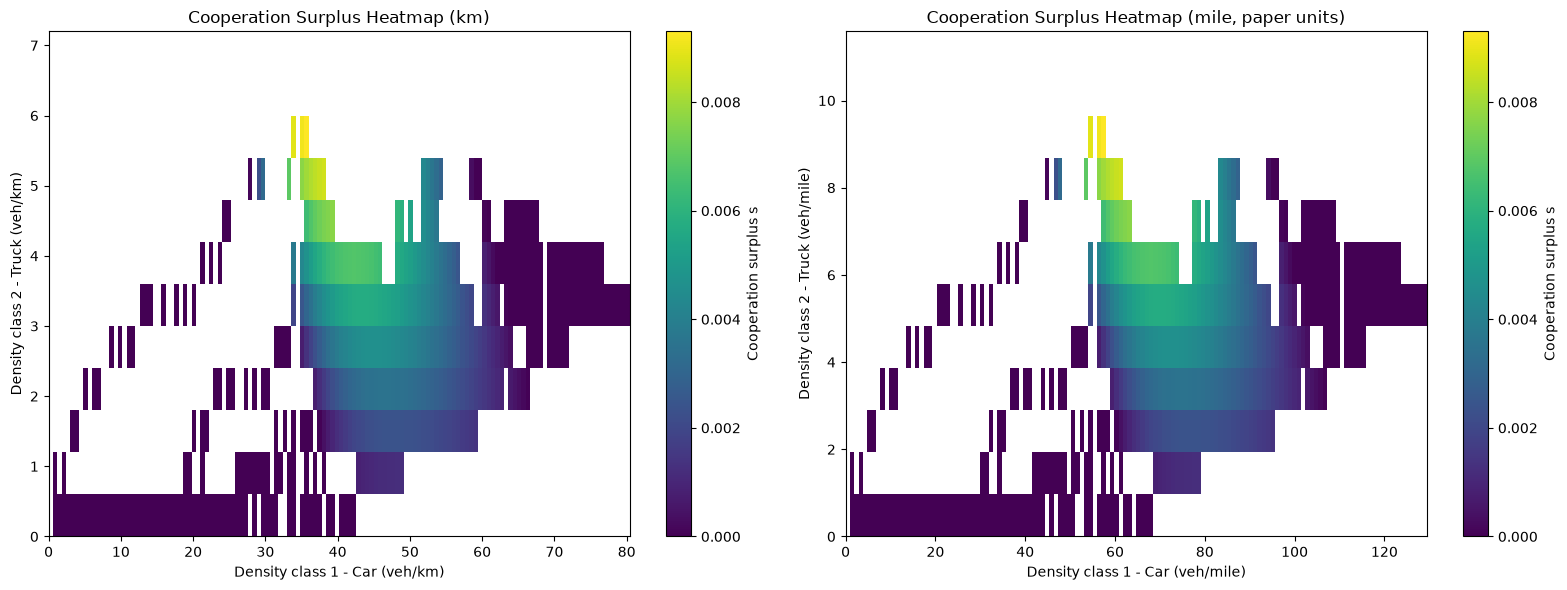

(               (-0.001, 0.6]    (0.6, 1.2]    (1.2, 1.8]    (1.8, 2.4]  \
 (-0.001, 0.6]            NaN  4.563017e-14  7.771561e-15  1.110223e-15   
 (0.6, 1.2]               NaN -2.651645e-01           NaN -4.370477e-01   
 (1.2, 1.8]               NaN           NaN           NaN           NaN   
 (1.8, 2.4]               NaN           NaN           NaN           NaN   
 (2.4, 3.0]               NaN           NaN           NaN           NaN   
 (3.0, 3.6]               NaN           NaN           NaN           NaN   
 (3.6, 4.2]               NaN           NaN           NaN           NaN   
 (4.2, 4.8]               NaN           NaN           NaN           NaN   
 (4.8, 5.4]               NaN           NaN           NaN           NaN   
 (5.4, 6.0]               NaN           NaN           NaN           NaN   
 (6.0, 6.6]               NaN           NaN           NaN           NaN   
 (6.6, 7.2]               NaN           NaN           NaN           NaN   
 
                  (2.4,

In [42]:
#macro_dataをdf_final(フィルタリング処理後データ)を用いて行うと、圧倒的に密度不足
#しかし、論文ではprocessed datasetと書かれており、処理後データセットとも読める
df_macro_data = compute_macroscopic_data(df, lanes=(2, 3, 4), classes=(2, 3), snapshot_step_frames=5 ,L_m=None)
#df_macro_data.head()

df_1pipe_full_data = compute_1pipe_speed_for_snapshots(
    df_macro_data,
    car_params=results_cc_strong_constraint,
    truck_params=results_tt_strong_constraint,
    a2=results_a2['scaling_param'],
    b1=results_b1['scaling_param'],
)
df_pstar_full = compute_min_road_share(df_1pipe_full_data, car_params=results_cc_strong_constraint, truck_params=results_tt_strong_constraint)
df_s_full = compute_cooperation_surplus(df_pstar_full)
plot_cooperation_surplus_heatmap(df_s_full, bin_width1=0.6, bin_width2=0.6, max_rho1=80, max_rho2=7, min_count=3)

#ただ、超過量が0.04ととても小さい(=閾値0.401に対してほぼギリギリ)ことを考えると、
# この「自前パラメータだと時々正になる」という現象自体、b1の推定誤差というノイズの範囲でたまたま境界をまたいでいるだけ、と捉えるのが妥当だと思います。
# 「本質的にs>0が成立しやすい」という強い主張ではなく、「たまたまわずかに超えた」というくらいの弱い現象です。

In [17]:
df_s_full.head(10)

,time_period,Global_Time,rho1,rho2,u1_obs,u2_obs,rho_tot,u_1pipe,p1_star,p2_star,s
0,1,1113433135300,0.000000,0.610694,NaN,12.157862,0.610694,66.254527,0.000000,1.000000,4.773959e-15
1,1,1113433135800,0.000000,0.610694,NaN,12.157862,0.610694,66.254527,0.000000,1.000000,4.773959e-15
2,1,1113433136300,0.610694,0.610694,13.716000,13.661136,1.221388,66.673992,0.028121,1.237043,-2.651645e-01
3,1,1113433136800,0.610694,0.610694,13.737946,13.781837,1.221388,66.673992,0.028121,1.237043,-2.651645e-01
4,1,1113433137300,0.610694,0.610694,15.756941,18.917107,1.221388,66.673992,0.028121,1.237043,-2.651645e-01
5,1,1113433137800,0.610694,0.610694,15.932506,19.399910,1.221388,66.673992,0.028121,1.237043,-2.651645e-01
6,1,1113433138300,0.610694,0.610694,14.385341,19.476720,1.221388,66.673992,0.028121,1.237043,-2.651645e-01
7,1,1113433138800,0.610694,0.610694,14.264640,19.279210,1.221388,66.673992,0.028121,1.237043,-2.651645e-01
8,1,1113433139300,0.610694,0.610694,14.264640,17.611344,1.221388,66.673992,0.028121,1.237043,-2.651645e-01
9,1,1113433139800,1.221388,0.610694,15.378379,19.509638,1.832082,66.789829,0.056337,1.323320,-3.796576e-01


In [18]:
df_macro_data.head(20)

,time_period,Global_Time,v_Class,n_vehicles,speed_kmh,density_veh_km,flow_veh_h
0,1,1113433135300,3,1,12.157862,0.610694,7.424735
1,1,1113433135800,3,1,12.157862,0.610694,7.424735
2,1,1113433136300,2,1,13.716000,0.610694,8.376280
3,1,1113433136300,3,1,13.661136,0.610694,8.342775
4,1,1113433136800,2,1,13.737946,0.610694,8.389682
5,1,1113433136800,3,1,13.781837,0.610694,8.416487
6,1,1113433137300,2,1,15.756941,0.610694,9.622671
7,1,1113433137300,3,1,18.917107,0.610694,11.552566
8,1,1113433137800,2,1,15.932506,0.610694,9.729887
9,1,1113433137800,3,1,19.399910,0.610694,11.847411


交通状態を判定(eps=6.0 km/h): 判定対象 5,932件 (対象外 undefined: 1,038件)
      2-pipe: 897件 (15.12%)
      1-pipe: 3,558件 (59.98%)
      non-NE: 1,477件 (24.90%)
  Pcoop = 15.12% (論文: 13.83%)
  平均s: 2-pipe = 0.0044, 1-pipe = 0.0028 (論文: 0.15, 0.11)
各time_periodの最初の100秒を除外: 6,970件 → 6,170件


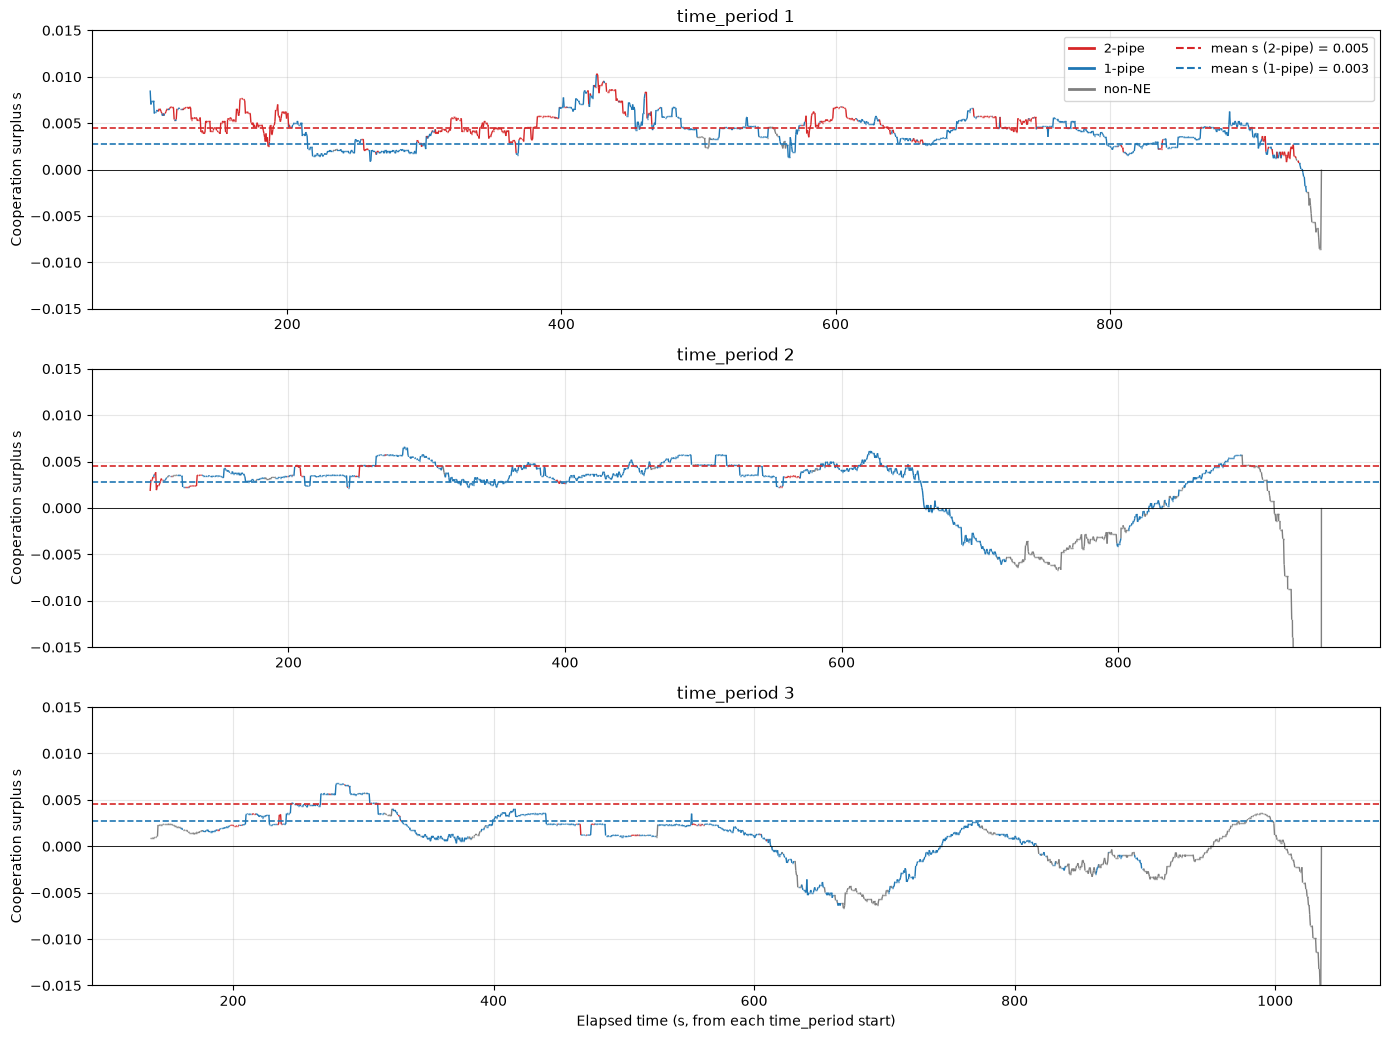

regime別の平均s: 2-pipe=0.005, 1-pipe=0.003  (論文: 2-pipe=0.15, 1-pipe=0.11)
協力性の存在判定: 判定対象 5,932件
  s>0             : 4,610件 (77.71%)
  2-pipe          : 897件 (15.12%)  ← 論文Pcoop=13.83%
  2-pipe かつ s>0 : 894件 (15.07%)  ← 協力性あり(Step6で使う)
  2-pipe かつ s<=0: 3件 (0.33% of 2-pipe)  ← 命題1と不整合


In [88]:
df_regime_full = classify_traffic_regime(df_s_full, eps_kmh=6.0)
#eps_kmhの値により2-pipeの割合が大幅に変化
plot_surplus_by_regime(df_regime_full,ylim=(-0.015, 0.015)) 
#df_s_use  = drop_warmup(df_s_full, skip_sec=100)
#df_regime = classify_traffic_regime(df_s_use, eps_kmh=6.0)                  # Step 4
df_coop   = check_cooperation_existence(df_regime_full)                          # Step 5
#plot_surplus_by_regime(df_regime, skip_sec=0)   # すでに除外済みなので0

λの推定に使うスナップショット(2-pipe かつ s>0): 894件
  学習 625件 / テスト 269件
  10-fold CV: λ = 0.0000 ± 0.0000, 重み付きMAE = 6.102 ± 0.158 km/h
  λ_hat = 0.0000  (論文: 0.8067)
  テストMAE: 車 5.247, トラック 7.153, 重み付き 6.200 km/h
           = 車 3.261, トラック 4.445, 重み付き 3.853 mph  (論文: 2.32, 1.45, 1.89 mph)


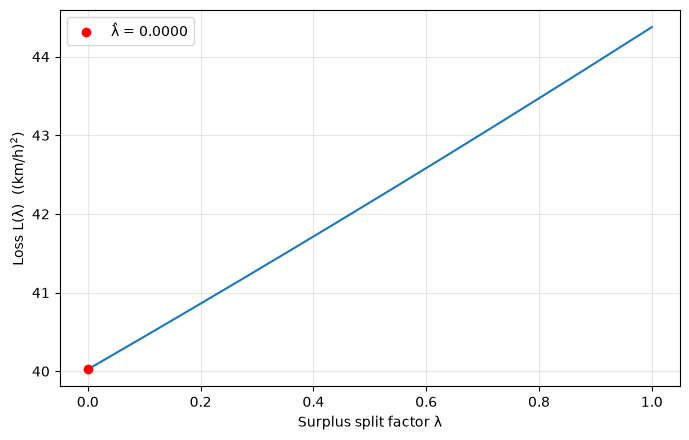

,fold,lambda,mae1,mae2,mae_weighted
0,1,0.000006,5.159853,7.179150,6.169502
1,2,0.000006,5.397878,7.262133,6.330005
2,3,0.000006,5.110673,7.377525,6.244099
3,4,0.000006,4.942243,7.416130,6.179186
4,5,0.000006,5.096196,6.776118,5.936157
5,6,0.000006,4.978820,6.729963,5.854391
6,7,0.000006,4.863538,7.432979,6.148258
7,8,0.000006,5.209233,6.622360,5.915797
8,9,0.000006,4.785683,7.268372,6.027027
9,10,0.000006,5.298357,7.125710,6.212034


(A) df_final: 車 1475台, トラック 53台  (論文: 1401台, 39台)
P1 = 0.9489, P2 = 0.0511
λ~1 = 0.000, λ~2 = 19.553, δ = 19.553  (論文: 0.84, 4.82, 3.98)
(B) 生データ レーン2〜4: 車 2684台, トラック 133台
P1 = 0.9308, P2 = 0.0692
λ~1 = 0.000, λ~2 = 14.454, δ = 14.454  (論文: 0.84, 4.82, 3.98)


In [89]:
res = estimate_surplus_split(df_coop, results_cc_strong_constraint, results_tt_strong_constraint)
plot_surplus_split_loss(res['train'], results_cc_strong_constraint, results_tt_strong_constraint, res['lambda_hat'])
display(res['cv'])   # foldごとのαとMAE（Fig.16に相当）

# (A) 論文と同じ考え方：df_final（フィルタ後の追従データ）に出てくる車両の台数
veh_final = df_final[['time_period', 'Vehicle_ID', 'v_Class']].drop_duplicates()
n_car_A   = (veh_final['v_Class'] == 2).sum()
n_truck_A = (veh_final['v_Class'] == 3).sum()
print(f"(A) df_final: 車 {n_car_A}台, トラック {n_truck_A}台  (論文: 1401台, 39台)")
eq_A = compute_equity_metric(res['lambda_hat'], n_car=n_car_A, n_truck=n_truck_A)

# (B) マクロデータと同じ範囲：生データdfのレーン2〜4に一度でも現れた車両の台数
veh_raw = df[df['Lane_ID'].isin([2, 3, 4]) & df['v_Class'].isin([2, 3])]
veh_raw = veh_raw[['time_period', 'Vehicle_ID', 'v_Class']].drop_duplicates()
n_car_B   = (veh_raw['v_Class'] == 2).sum()
n_truck_B = (veh_raw['v_Class'] == 3).sum()
print(f"(B) 生データ レーン2〜4: 車 {n_car_B}台, トラック {n_truck_B}台")
eq_B = compute_equity_metric(res['lambda_hat'], n_car=n_car_B, n_truck=n_truck_B)

### 交通状態(1-pipe,2-pipe,non-NE)を判定

In [ ]:
#################################################################################
# Step 4: 交通状態(traffic regime)の判定  論文Eq(11)
#   2-pipe : ũ1 >= u* かつ ũ2 >= u* (ただし両方"="は同時に成り立たない)
#   1-pipe : ũ1 = ũ2 = u*
#   上のどちらでもない → non-Pareto-efficient NE
# 実データの速度は連続値で"="が厳密には成り立たないので、|ũi - u*| <= eps を"="とみなす
# (論文にはepsの値は書かれていない)

def classify_traffic_regime(df_s, eps_kmh, u1_col='u1_obs', u2_col='u2_obs', u_star_col='u_1pipe', s_col='s'):
    """
    df_s: u1_obs, u2_obs, u_1pipe 列を含むスナップショット表
          (compute_cooperation_surplus の返り値など)
    eps_kmh: 観測速度と1-pipe速度が「等しい」とみなす許容幅(km/h)

    戻り値: df_s に以下の列を追加したコピー
      'du1', 'du2' : ũi - u*  (km/h)
      'regime'     : '2-pipe' / '1-pipe' / 'non-Pareto' / 'undefined'
                     'undefined' = 片方のクラスがいない、またはu*が解けなかったスナップショット
    """
    df = df_s.copy()

    #観測速度とu*の差を計算する
    df['du1'] = df[u1_col] - df[u_star_col]
    df['du2'] = df[u2_col] - df[u_star_col]

    #両クラスの観測速度とu*が存在する行だけ判定対象にする
    #片方のクラスがいない時刻などは判定できないため除外
    valid = df[['du1', 'du2']].notna().all(axis=1)

    #判定に使う条件
    eq1 = df['du1'].abs() <= eps_kmh   #ũ1 = u* とみなせる
    eq2 = df['du2'].abs() <= eps_kmh   #ũ2 = u* とみなせる
    ge1 = df['du1'] >= -eps_kmh        #ũ1 >= u* (許容幅込み)
    ge2 = df['du2'] >= -eps_kmh        #ũ2 >= u* (許容幅込み)

    #car,truckともに=1pipespeedなら、1pipe
    is_1pipe = valid & eq1 & eq2
    #どちらも1pipe速度以上かつ、両方1pipe速度とも判定できるときは1pipeなので除外
    is_2pipe = valid & ge1 & ge2 & ~(eq1 & eq2)   #両方"="の場合は1-pipeなので除く

    #まずすべてをnon-NEとしておく
    df['regime'] = 'non-NE'
    #それぞれの基準に従い命名
    df.loc[is_2pipe, 'regime'] = '2-pipe'
    df.loc[is_1pipe, 'regime'] = '1-pipe'
    df.loc[~valid, 'regime'] = 'undefined'

    #集計の表示  論文Eq(21): Pcoop = N_2pipe / N_tot (N_totは2-pipe,1-pipe,non-Paretoの合計)命題1（2-pipe ⇔ s>0）
    counts = df['regime'].value_counts()#regimeごとの件数を数える
    n_tot = int(valid.sum())
    n_2pipe = int(counts.get('2-pipe', 0))#2-pipeが1件もなかった場合でも０を返す
    print(f"交通状態を判定(eps={eps_kmh} km/h): 判定対象 {n_tot:,}件 "
          f"(対象外 undefined: {int(counts.get('undefined', 0)):,}件)")
    for r in ['2-pipe', '1-pipe', 'non-NE']:
        n = int(counts.get(r, 0))
        pct = 100 * n / n_tot if n_tot > 0 else float('nan')
        print(f"  {r:>10}: {n:,}件 ({pct:.2f}%)")
    if n_tot > 0:
        print(f"  Pcoop = {100 * n_2pipe / n_tot:.2f}% (論文: 13.83%)")

    #regime別の協力余剰sの平均（論文Fig.13の水平線: 2-pipe 0.15, 1-pipe 0.11）
    #s列がない表を渡した場合(sを計算する前のデータなど)は表示しない
    if s_col in df.columns:
        mean_s_2pipe = df.loc[df['regime'] == '2-pipe', s_col].mean()
        mean_s_1pipe = df.loc[df['regime'] == '1-pipe', s_col].mean()
        print(f"  平均s: 2-pipe = {mean_s_2pipe:.4f}, 1-pipe = {mean_s_1pipe:.4f} "
              f"(論文: 0.15, 0.11)")
    return df


In [58]:
df_regime_full = classify_traffic_regime(df_s_full, eps_kmh=6.0)
#eps_kmhの値により2-pipeの割合が大幅に変化

交通状態を判定(eps=6.0 km/h): 判定対象 5,932件 (対象外 undefined: 1,038件)
      2-pipe: 897件 (15.12%)
      1-pipe: 3,558件 (59.98%)
      non-NE: 1,477件 (24.90%)
  Pcoop = 15.12% (論文: 13.83%)
  平均s: 2-pipe = 0.0044, 1-pipe = 0.0028 (論文: 0.15, 0.11)


各time_periodの最初の100秒を除外: 6,970件 → 6,170件


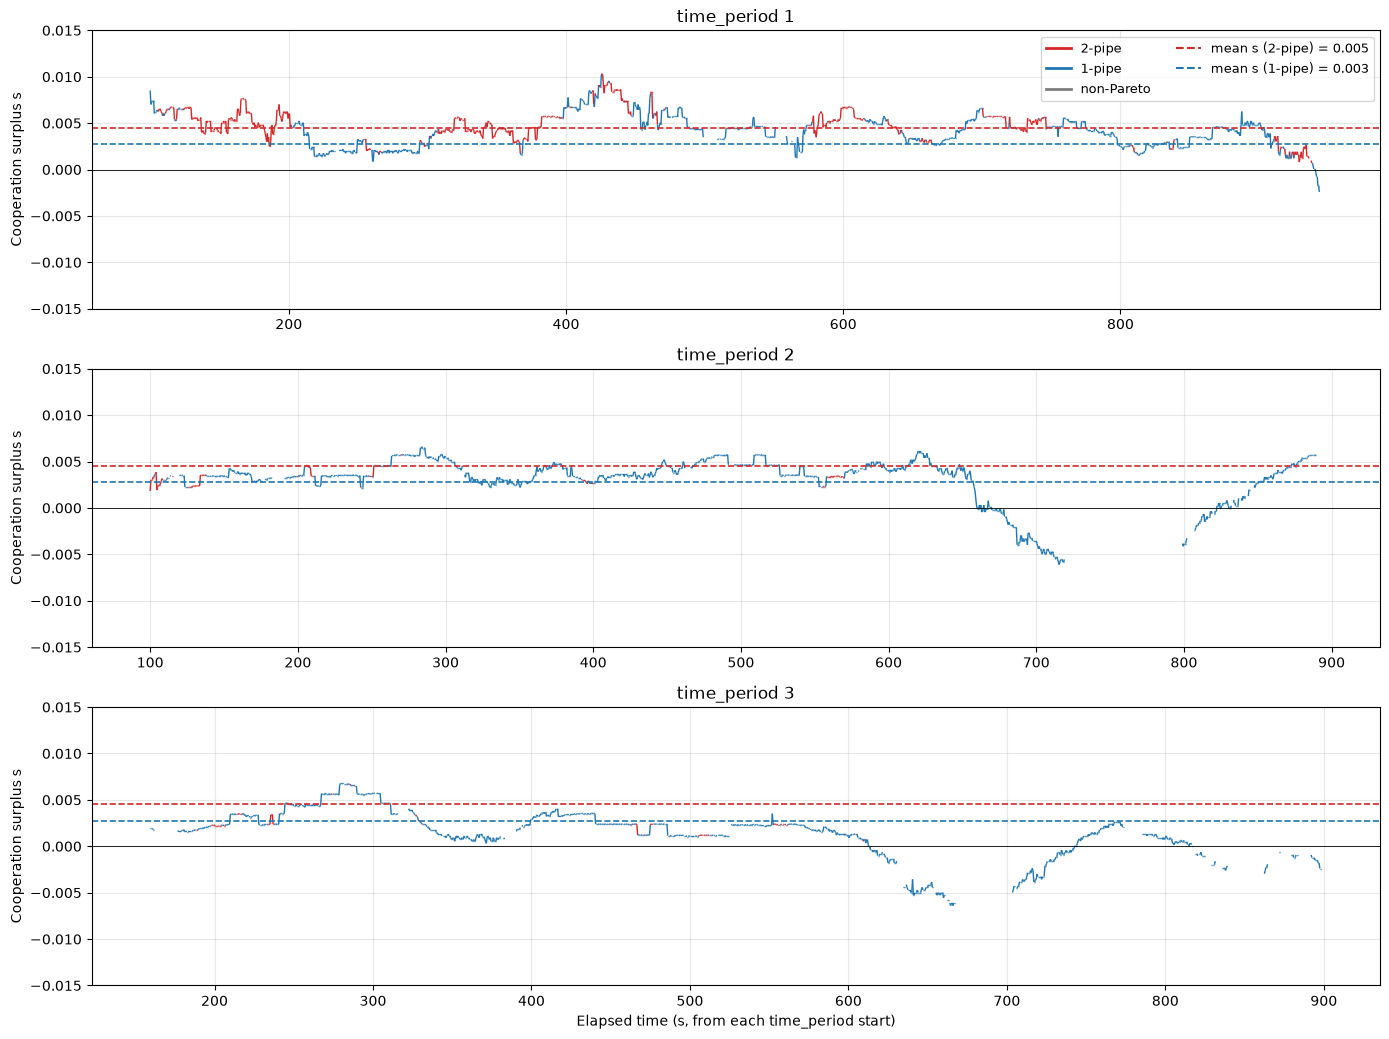

regime別の平均s: 2-pipe=0.005, 1-pipe=0.003  (論文: 2-pipe=0.15, 1-pipe=0.11)


In [59]:
plot_surplus_by_regime(df_regime_full,ylim=(-0.015, 0.015))                       # 最初の100秒を除外、y軸 -0.1〜0.1

区間長: 545.8 m, 車線数: 3

--マクロ密度・平均速度を計算--
1-pipe速度を計算: 6,970スナップショット中、6,970件で解を取得
最小道路占有を計算: 6,970スナップショット中、6,970件で計算完了
協力余剰sを計算: 6,970スナップショット中、6,970件で計算完了（うちs>0: 395件）
交通状態を判定(eps=10.0 km/h): 判定対象 5,932件 (対象外 undefined: 1,038件)
      2-pipe: 1件 (0.02%)
      1-pipe: 2,909件 (49.04%)
  non-Pareto: 3,022件 (50.94%)
  Pcoop = 0.02% (論文: 13.83%)
各time_periodの最初の100秒を除外: 6,970件 → 6,170件


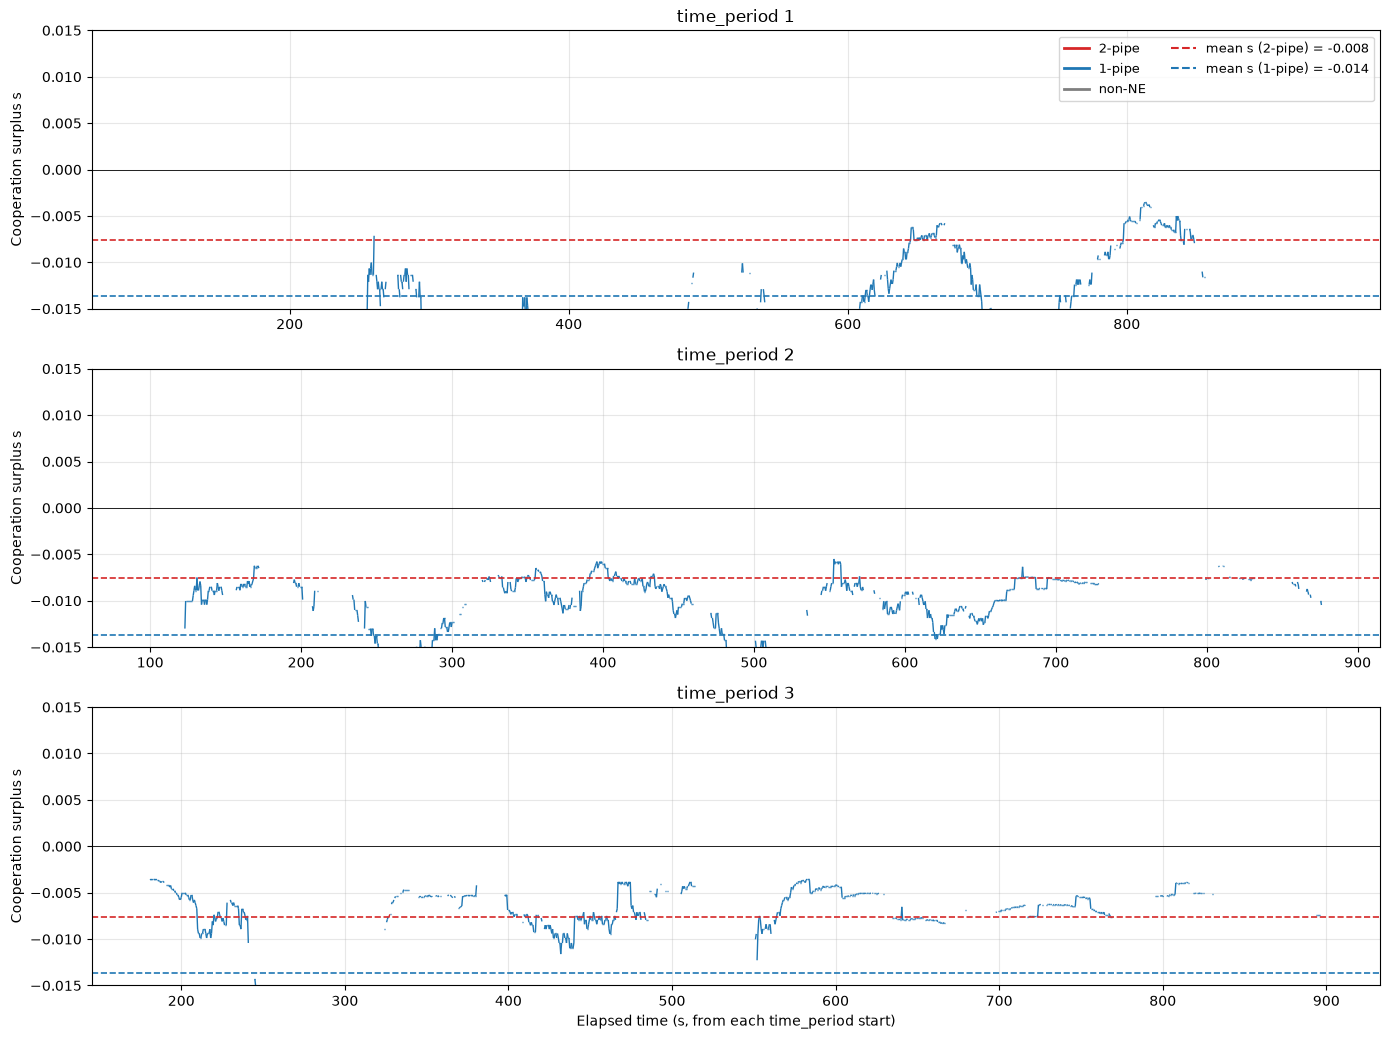

regime別の平均s: 2-pipe=-0.008, 1-pipe=-0.014  (論文: 2-pipe=0.15, 1-pipe=0.11)


In [65]:
#macro_dataをdf_final(フィルタリング処理後データ)を用いて行うと、圧倒的に密度不足
#しかし、論文ではprocessed datasetと書かれており、処理後データセットとも読める
df_macro_data = compute_macroscopic_data(df, lanes=(2, 3, 4), classes=(2, 3), snapshot_step_frames=5 ,L_m=None)
#df_macro_data.head()

df_1pipe_paper_data = compute_1pipe_speed_for_snapshots(
    df_macro_data,
    car_params=results_cc_paper_km,
    truck_params=results_tt_paper_km,
    a2=results_a2_paper_km['scaling_param'],
    b1=results_b1_paper_km['scaling_param'],
)
df_pstar_paper = compute_min_road_share(df_1pipe_paper_data, car_params=results_cc_paper_km, truck_params=results_tt_paper_km)
df_s_paper = compute_cooperation_surplus(df_pstar_paper)
#plot_cooperation_surplus_heatmap(df_s_paper, bin_width1=0.6, bin_width2=0.6, max_rho1=80, max_rho2=7, min_count=3)

df_regime_paper = classify_traffic_regime(df_s_paper, eps_kmh=10.0)
#eps_kmhの値により2-pipeの割合が大幅に変化

plot_surplus_by_regime(df_regime_paper,ylim=(-0.015, 0.015))   

In [ ]:
#############################################################################
# 立ち上がり部分(各time_periodの最初のskip_sec秒)を除外する補助関数
# Step4以降(集計・プロット・αの推定)で同じデータ範囲を使うために、Step4の前にかける
def drop_warmup(df, skip_sec=100):
    """
    df: time_period, Global_Time列を含むスナップショット表
    skip_sec: 各time_periodの開始からこの秒数未満の行を除外する
    """
    t0 = df.groupby('time_period')['Global_Time'].transform('min')
    elapsed_sec = (df['Global_Time'] - t0) / 1000
    out = df[elapsed_sec >= skip_sec].copy()
    print(f"各time_periodの最初の{skip_sec}秒を除外: {len(df):,}件 → {len(out):,}件")
    return out




    return df

### 協力性の判定

In [ ]:
#############################################################################
# Step 5: 協力性(collective cooperativeness)の存在判定  論文4.3.3
#   存在する ⇔ s > 0 かつ 交通状態が2-pipe
def check_cooperation_existence(df_regime, s_col='s', regime_col='regime'):
    """
    df_regime: classify_traffic_regime の返り値（s, regime列を含む）

    戻り値: df_regime に 'coop_exists'(bool) 列を追加したコピー
            Step6(αの推定)では df[df['coop_exists']] を使う
    """
    df = df_regime.copy()

    is_2pipe = df[regime_col] == '2-pipe'
    s_pos = df[s_col] > 0
    df['coop_exists'] = is_2pipe & s_pos

    #判定対象(undefinedを除く)での集計
    judged = df[regime_col] != 'undefined'
    n_tot = int(judged.sum())
    n_2pipe = int(is_2pipe.sum())
    n_exist = int(df['coop_exists'].sum())
    n_spos = int((s_pos & judged).sum())
    #命題1では 2-pipe ⇔ s>0 なので、2-pipeなのにs<=0の行はモデルと観測が合っていない行
    n_2pipe_sneg = int((is_2pipe & ~s_pos).sum())

    def pct(n, d):
        return 100 * n / d if d > 0 else float('nan')

    print(f"協力性の存在判定: 判定対象 {n_tot:,}件")
    print(f"  s>0             : {n_spos:,}件 ({pct(n_spos, n_tot):.2f}%)")
    print(f"  2-pipe          : {n_2pipe:,}件 ({pct(n_2pipe, n_tot):.2f}%)  ← 論文Pcoop=13.83%")
    print(f"  2-pipe かつ s>0 : {n_exist:,}件 ({pct(n_exist, n_tot):.2f}%)  ← 協力性あり(Step6で使う)")
    print(f"  2-pipe かつ s<=0: {n_2pipe_sneg:,}件 ({pct(n_2pipe_sneg, n_2pipe):.2f}% of 2-pipe)  ← 命題1と不整合")

各time_periodの最初の100秒を除外: 6,970件 → 6,170件
交通状態を判定(eps=6.0 km/h): 判定対象 5,588件 (対象外 undefined: 582件)
      2-pipe: 862件 (15.43%)
      1-pipe: 3,441件 (61.58%)
  non-Pareto: 1,285件 (23.00%)
  Pcoop = 15.43% (論文: 13.83%)
協力性の存在判定: 判定対象 5,588件
  s>0             : 4,467件 (79.94%)
  2-pipe          : 862件 (15.43%)  ← 論文Pcoop=13.83%
  2-pipe かつ s>0 : 862件 (15.43%)  ← 協力性あり(Step6で使う)
  2-pipe かつ s<=0: 0件 (0.00% of 2-pipe)  ← 命題1と不整合
各time_periodの最初の0秒を除外: 6,170件 → 6,170件


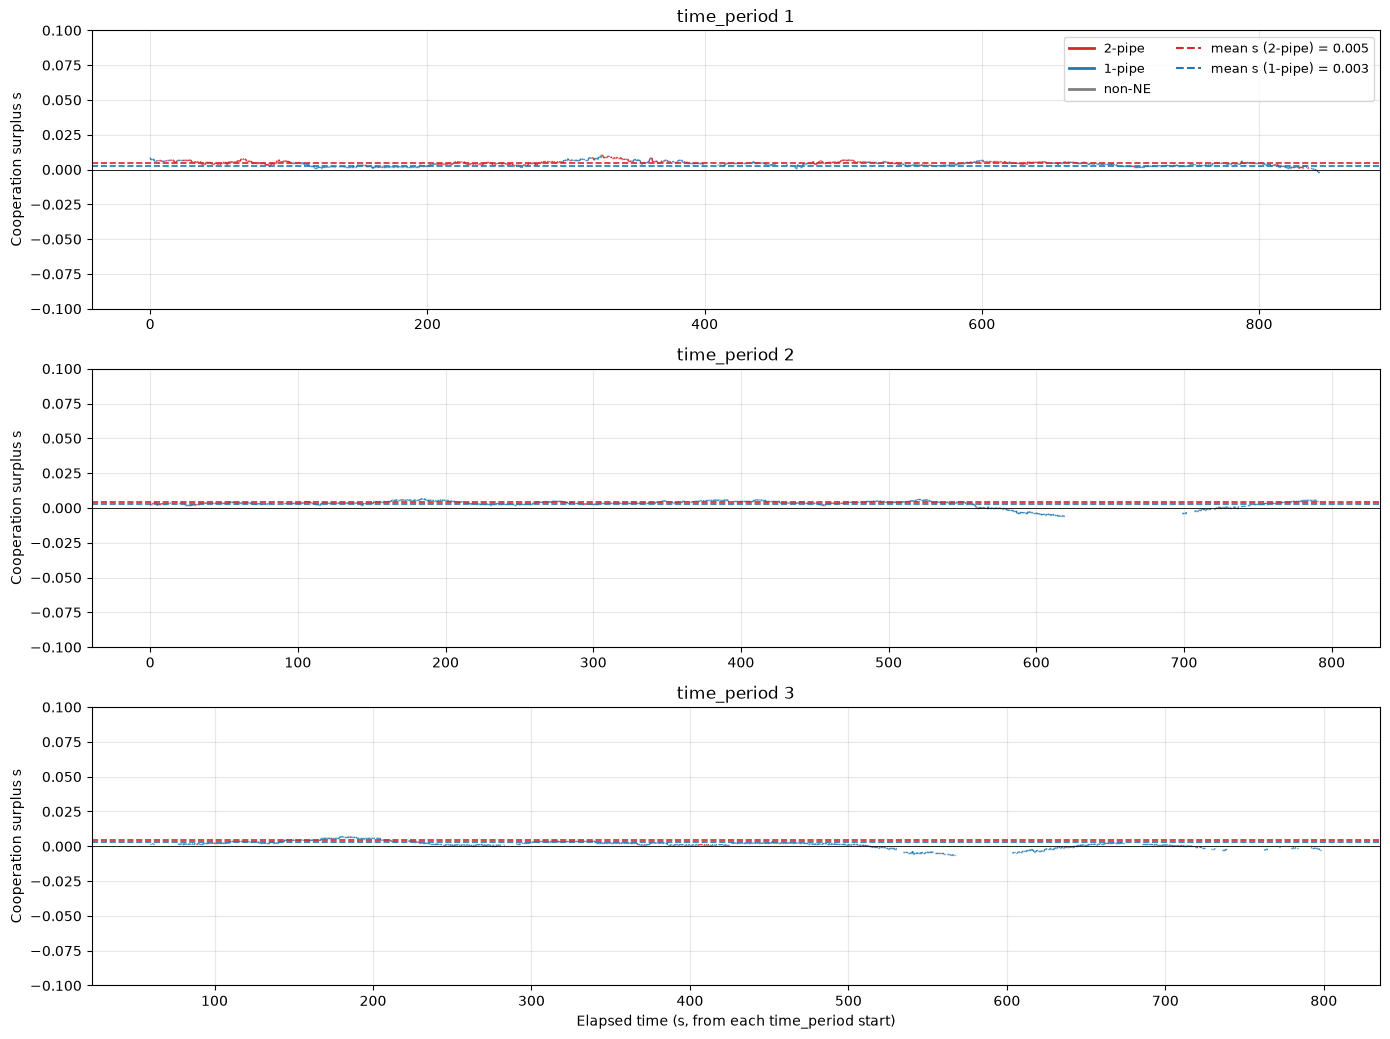

regime別の平均s: 2-pipe=0.005, 1-pipe=0.003  (論文: 2-pipe=0.15, 1-pipe=0.11)


In [66]:
df_s_use  = drop_warmup(df_s_full, skip_sec=100)
df_regime = classify_traffic_regime(df_s_use, eps_kmh=6.0)                  # Step 4
df_coop   = check_cooperation_existence(df_regime)                          # Step 5
plot_surplus_by_regime(df_regime, skip_sec=0)   # すでに除外済みなので0

In [31]:
df_s_full["u_1pipe"].mean

<bound method Series.mean of 0        66.254527
1        66.254527
2        66.673992
3        66.673992
4        66.673992
           ...    
6965    115.309211
6966    115.309211
6967    115.309211
6968    115.309211
6969    115.309211
Name: u_1pipe, Length: 6970, dtype: float64>

In [30]:
df_s_full.head()

,time_period,Global_Time,rho1,rho2,u1_obs,u2_obs,rho_tot,u_1pipe,p1_star,p2_star,s
0,1,1113433135300,0.000000,0.610694,NaN,12.157862,0.610694,66.254527,0.000000,1.000000,4.773959e-15
1,1,1113433135800,0.000000,0.610694,NaN,12.157862,0.610694,66.254527,0.000000,1.000000,4.773959e-15
2,1,1113433136300,0.610694,0.610694,13.716000,13.661136,1.221388,66.673992,0.028121,1.237043,-2.651645e-01
3,1,1113433136800,0.610694,0.610694,13.737946,13.781837,1.221388,66.673992,0.028121,1.237043,-2.651645e-01
4,1,1113433137300,0.610694,0.610694,15.756941,18.917107,1.221388,66.673992,0.028121,1.237043,-2.651645e-01


In [ ]:
# (c) 論文パラメータで計算（全車両 df からマクロデータを作り直す）
# 実測速度に対して1-pipe速度がかなり大きいため2-pipeが0になる
df_macro_full = compute_macroscopic_data(df, lanes=(2, 3, 4), classes=(2, 3), snapshot_step_frames=5)

df_1pipe_paper = compute_1pipe_speed_for_snapshots(
    df_macro_full,
    car_params=results_cc_paper_km,
    truck_params=results_tt_paper_km,
    a2=results_a2_paper_km['scaling_param'],
    b1=results_b1_paper_km['scaling_param'],
)
df_pstar_paper = compute_min_road_share(df_1pipe_paper, car_params=results_cc_paper_km, truck_params=results_tt_paper_km)
df_s_paper = compute_cooperation_surplus(df_pstar_paper)

df_regime_paper = classify_traffic_regime(drop_warmup(df_s_paper, 100), eps_kmh=2.0)
df_coop_paper = check_cooperation_existence(df_regime_paper)
d_p = df_regime_paper[df_regime_paper['regime'] != 'undefined']
print(d_p[['du1', 'du2']].describe())

区間長: 545.8 m, 車線数: 3

--マクロ密度・平均速度を計算--
1-pipe速度を計算: 6,970スナップショット中、6,970件で解を取得
最小道路占有を計算: 6,970スナップショット中、6,970件で計算完了
協力余剰sを計算: 6,970スナップショット中、6,970件で計算完了（うちs>0: 395件）
各time_periodの最初の100秒を除外: 6,970件 → 6,170件
交通状態を判定(eps=2.0 km/h): 判定対象 5,588件 (対象外 undefined: 582件)
      2-pipe: 0件 (0.00%)
      1-pipe: 1件 (0.02%)
  non-Pareto: 5,587件 (99.98%)
  Pcoop = 0.00% (論文: 13.83%)
協力性の存在判定: 判定対象 5,588件
  s>0             : 0件 (0.00%)
  2-pipe          : 0件 (0.00%)  ← 論文Pcoop=13.83%
  2-pipe かつ s>0 : 0件 (0.00%)  ← 協力性あり(Step6で使う)
  2-pipe かつ s<=0: 0件 (nan% of 2-pipe)  ← 命題1と不整合
               du1          du2
count  5588.000000  5588.000000
mean    -10.050680   -10.259181
std       6.675816     7.094933
min     -48.847224   -46.553843
25%      -9.991662   -12.373122
50%      -8.557172    -9.119127
75%      -7.224929    -6.122054
max       0.134204    13.100205


In [ ]:
# no constraintデータで試す（全車両 df からマクロデータを作り直す）
# 1-pipe速度がかなり狭い幅に押し込まれてしまう。
#命題１と矛盾する結果となってしまう
#交通が流れていて観測速度が 20 km/h を超えても、u* はそれ以上高くなれません。
# そのため「観測速度 > u*」となり、2-pipe と判定されます。
# つまり Pcoop 46% も、「2-pipe かつ s≤0」の 723 件も、どちらもトラックの uf=20 という上限が作り出した見かけの結果です。

df_macro_full = compute_macroscopic_data(df, lanes=(2, 3, 4), classes=(2, 3), snapshot_step_frames=5)

# 制約なし(no constraint)で推定したパラメータ
results_cc_no_constraint = {
    'mode_id': 1, 'ub': 0.006, 'uf': 38.066, 'rhoc': 68.729,
    'theta1': 29.723, 'theta2': 1.138, 'test_mae': 5.283
}

results_ct_no_constraint = {
    'mode_id': 2, 'ub': 10.599, 'uf': 49.849, 'rhoc': 30.106,
    'theta1': 8.057, 'theta2': 2.807, 'test_mae': 6.486
}

results_tt_no_constraint = {
    'mode_id': 4, 'uf': 20.000, 'rhoc': 100.000, 'test_mae': 5.657
}

results_tc_no_constraint = {
    'mode_id': 3, 'uf': 30.413, 'rhoc': 67.335, 'test_mae': 5.424
}

results_a2_no_constraint = {
    'mode_id': 2, 'scaling_param': 0.4851, 'test_mae': 7.363
}
results_b1_no_constraint = {
    'mode_id': 3, 'scaling_param': 1.1126, 'test_mae': 5.582
}

df_1pipe_nc = compute_1pipe_speed_for_snapshots(
    df_macro_full,
    car_params=results_cc_no_constraint,
    truck_params=results_tt_no_constraint,
    a2=results_a2_no_constraint['scaling_param'],
    b1=results_b1_no_constraint['scaling_param'],
)
df_pstar_nc = compute_min_road_share(df_1pipe_nc, car_params=results_cc_no_constraint, truck_params=results_tt_no_constraint)
df_s_nc = compute_cooperation_surplus(df_pstar_nc)

df_regime_nc = classify_traffic_regime(drop_warmup(df_s_nc, 100), eps_kmh=2.0)
df_coop_nc = check_cooperation_existence(df_regime_nc)
d_nc = df_regime_nc[df_regime_nc['regime'] != 'undefined']
print(d_nc[['du1', 'du2']].describe())

区間長: 545.8 m, 車線数: 3

--マクロ密度・平均速度を計算--
1-pipe速度を計算: 6,970スナップショット中、6,970件で解を取得
最小道路占有を計算: 6,970スナップショット中、6,970件で計算完了
協力余剰sを計算: 6,970スナップショット中、6,970件で計算完了（うちs>0: 5,194件）
各time_periodの最初の100秒を除外: 6,970件 → 6,170件
交通状態を判定(eps=2.0 km/h): 判定対象 5,588件 (対象外 undefined: 582件)
      2-pipe: 2,578件 (46.13%)
      1-pipe: 553件 (9.90%)
  non-Pareto: 2,457件 (43.97%)
  Pcoop = 46.13% (論文: 13.83%)
協力性の存在判定: 判定対象 5,588件
  s>0             : 4,493件 (80.40%)
  2-pipe          : 2,578件 (46.13%)  ← 論文Pcoop=13.83%
  2-pipe かつ s>0 : 1,855件 (33.20%)  ← 協力性あり(Step6で使う)
  2-pipe かつ s<=0: 723件 (28.04% of 2-pipe)  ← 命題1と不整合
               du1          du2
count  5588.000000  5588.000000
mean      1.266609     1.058108
std       5.920425     6.636334
min     -10.479287   -17.331586
25%      -3.809532    -3.977518
50%       0.699241     0.414508
75%       6.149683     5.773765
max      15.259557    22.020622


各time_periodの最初の0秒を除外: 6,170件 → 6,170件


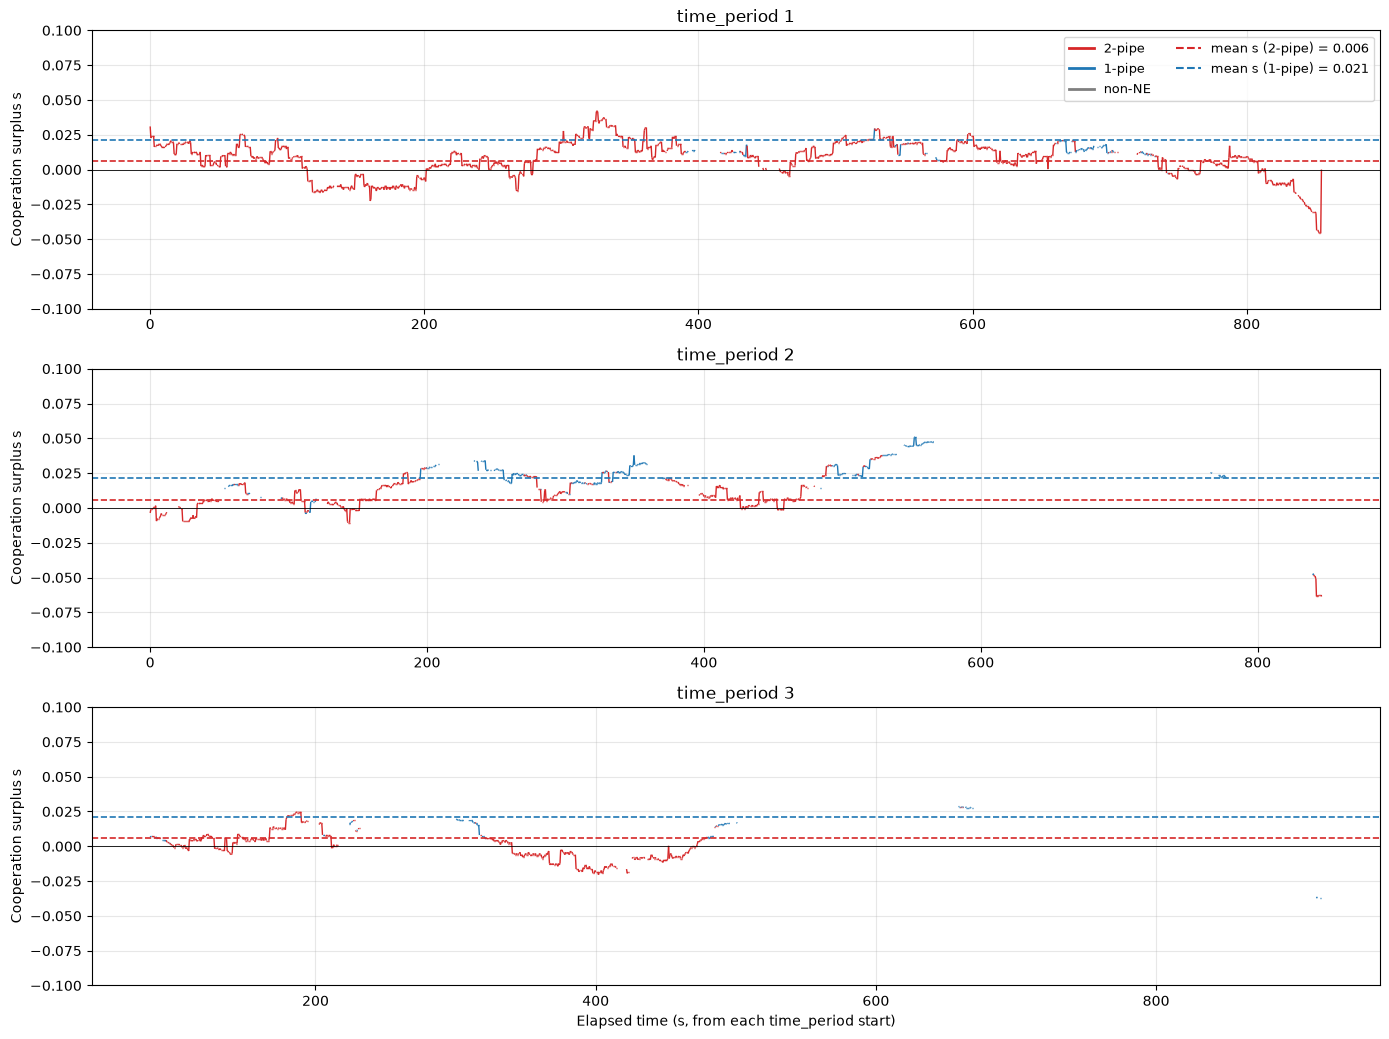

regime別の平均s: 2-pipe=0.006, 1-pipe=0.021  (論文: 2-pipe=0.15, 1-pipe=0.11)


In [71]:
plot_surplus_by_regime(df_regime_nc, skip_sec=0)   # すでに除外済みなので0

In [70]:
r = df_regime_nc[df_regime_nc['regime'] != 'undefined']

# (1) u*が20 km/h付近に張り付いていないか
print(r['u_1pipe'].describe())

# (2) u*の速度帯ごとのsの平均と、2-pipeかつs<=0の件数
bins = pd.cut(r['u_1pipe'], bins=[0, 5, 10, 15, 18, 19, 19.5, 20])
print(r.groupby(bins, observed=True).agg(
    n=('s', 'size'),
    mean_s=('s', 'mean'),
    n_2pipe=('regime', lambda x: (x == '2-pipe').sum()),
    n_2pipe_sneg=('s', lambda x: ((x <= 0) & (r.loc[x.index, 'regime'] == '2-pipe')).sum()),
))

count    5588.000000
mean       17.442766
std         1.868189
min        11.441961
25%        16.727440
50%        18.131015
75%        18.663742
max        19.840906
Name: u_1pipe, dtype: float64
                 n    mean_s  n_2pipe  n_2pipe_sneg
u_1pipe                                            
(10.0, 15.0]   813  0.034071        0             0
(15.0, 18.0]  1706  0.024158      412             0
(18.0, 19.0]  2256  0.007564     1637           194
(19.0, 19.5]   595 -0.012077      428           428
(19.5, 20.0]   218 -0.032114      101           101


In [ ]:
# 論文Fig.14風：密度(ρ1, ρ2)の格子ごとに、交通状態(2-pipe / 1-pipe / non-NE)の分布をヒートマップで表示する
def plot_regime_heatmap(df_regime, bin_width1=1.5, bin_width2=0.5, max_rho1=80, max_rho2=7,
                        min_count=3, regime_col='regime', colors=None, in_vpm=False):
    """
    左端: 各マスで最も多い交通状態(多数派)を色分け
    残り: 各マスに占める各交通状態の割合(0〜1)

    df_regime: classify_traffic_regime の返り値（rho1, rho2, regime列を含む）
    bin_width1, bin_width2: 車・トラック密度のマスの幅（in_vpm=Trueならveh/mile単位）
    max_rho1, max_rho2: 表示する密度の上限
    min_count: スナップショット数がこれ未満のマスは表示しない（少数サンプルのノイズ除け）
    colors: regimeごとの色の辞書。undefinedなど辞書にないregimeは集計から除く
    in_vpm: Trueなら密度をveh/mile(論文の単位)に換算して表示
    """
    if colors is None:
        colors = {'2-pipe': 'tab:red', '1-pipe': 'tab:blue', 'non-NE': 'tab:gray'}
    regimes = list(colors)

    #判定できたスナップショットだけを使う
    d = df_regime[df_regime[regime_col].isin(regimes)].copy()
    scale = KM_TO_MILE if in_vpm else 1.0   #veh/km → veh/mile は1.60934倍
    unit = 'veh/mile' if in_vpm else 'veh/km'
    d['r1'] = d['rho1'] * scale
    d['r2'] = d['rho2'] * scale

    #マスの境界を作り、各スナップショットがどのマスに入るかを番号で求める
    edges1 = np.arange(0, max_rho1 + bin_width1, bin_width1)
    edges2 = np.arange(0, max_rho2 + bin_width2, bin_width2)
    d['b1'] = pd.cut(d['r1'], edges1, labels=False, right=False)
    d['b2'] = pd.cut(d['r2'], edges2, labels=False, right=False)
    d = d.dropna(subset=['b1', 'b2'])   #表示範囲の外にあるものは除く

    #マスごと・regimeごとの件数を数え、件数が少ないマスは除く
    counts = (d.groupby(['b1', 'b2', regime_col]).size()
                .unstack(fill_value=0).reindex(columns=regimes, fill_value=0))
    total = counts.sum(axis=1)
    counts = counts[total >= min_count]
    share = counts.div(counts.sum(axis=1), axis=0)

    #pcolormesh用の2次元配列(行=トラック密度, 列=車密度)に並べ直す
    n1, n2 = len(edges1) - 1, len(edges2) - 1
    def to_grid(values):
        grid = np.full((n2, n1), np.nan)
        for (b1, b2), v in values.items():
            grid[int(b2), int(b1)] = v
        return grid

    #各マスで最も多いregimeの番号(colorsの並び順: 0, 1, 2)
    majority = to_grid(pd.Series(share.values.argmax(axis=1), index=share.index))

    fig, axes = plt.subplots(1, len(regimes) + 1, figsize=(5 * (len(regimes) + 1), 4.5),
                             sharex=True, sharey=True)

    #多数派のregime（カテゴリの色分け）
    cmap = ListedColormap([colors[r] for r in regimes])
    norm = BoundaryNorm(np.arange(-0.5, len(regimes)), cmap.N)
    axes[0].pcolormesh(edges1, edges2, majority, cmap=cmap, norm=norm)
    axes[0].set_title('Majority regime')
    axes[0].legend(handles=[Patch(color=colors[r], label=r) for r in regimes],
                   loc='upper right', fontsize=9)

    #各regimeの割合
    for ax, r in zip(axes[1:], regimes):
        mesh = ax.pcolormesh(edges1, edges2, to_grid(share[r]), cmap='viridis', vmin=0, vmax=1)
        ax.set_title(f'Share of {r}')
        fig.colorbar(mesh, ax=ax, label='share')

    for ax in axes:
        ax.set_xlabel(f'Car density ρ1 ({unit})')
        ax.grid(alpha=0.2)
    axes[0].set_ylabel(f'Truck density ρ2 ({unit})')
    plt.tight_layout()
    plt.show()

    print(f"表示したマス: {len(counts)}個 (スナップショット{min_count}件未満のマスは非表示)")
    return counts

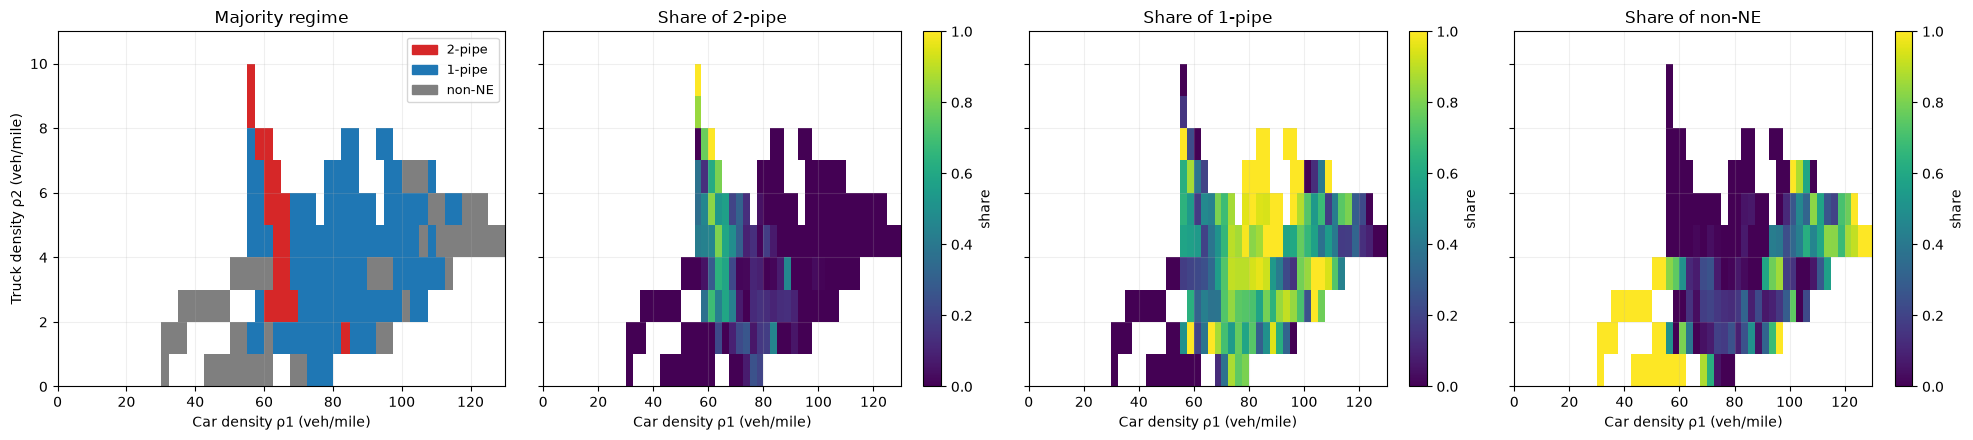

表示したマス: 167個 (スナップショット3件未満のマスは非表示)


In [90]:
# 論文と同じ veh/mile で表示（Fig.11/12の軸に合わせる場合）
counts = plot_regime_heatmap(df_regime, in_vpm=True, bin_width1=2.5, bin_width2=1.0,
                             max_rho1=130, max_rho2=11)

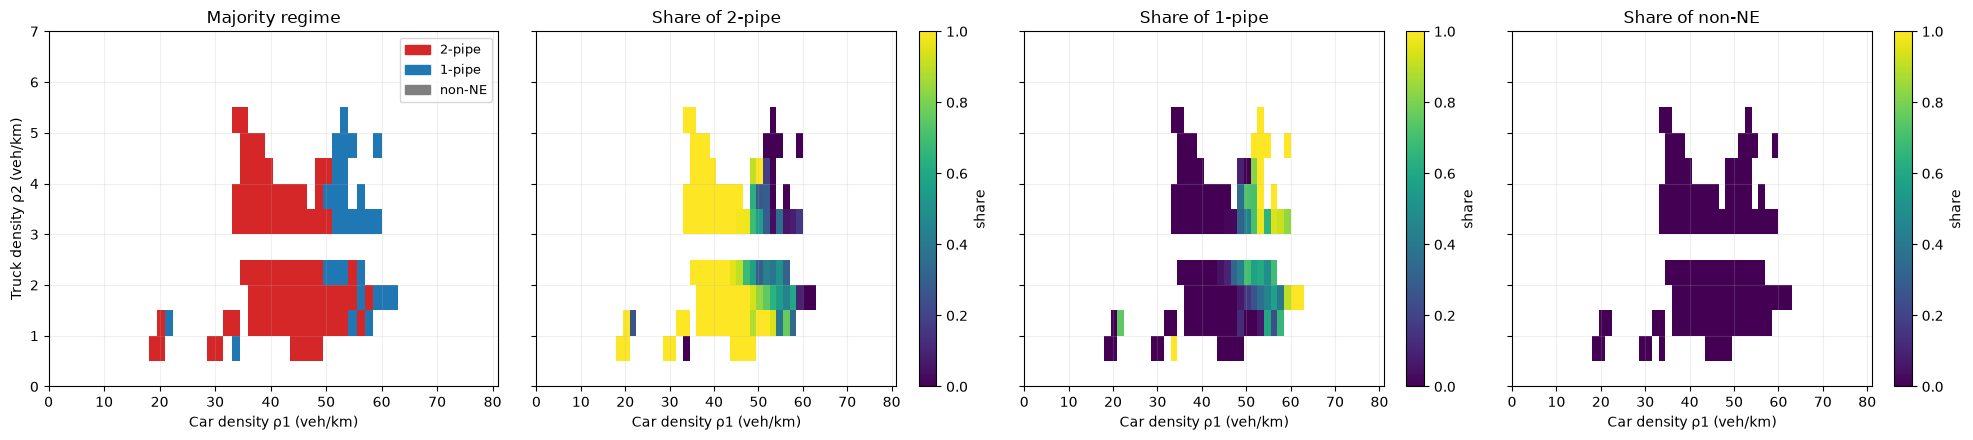

表示したマス: 111個 (スナップショット3件未満のマスは非表示)


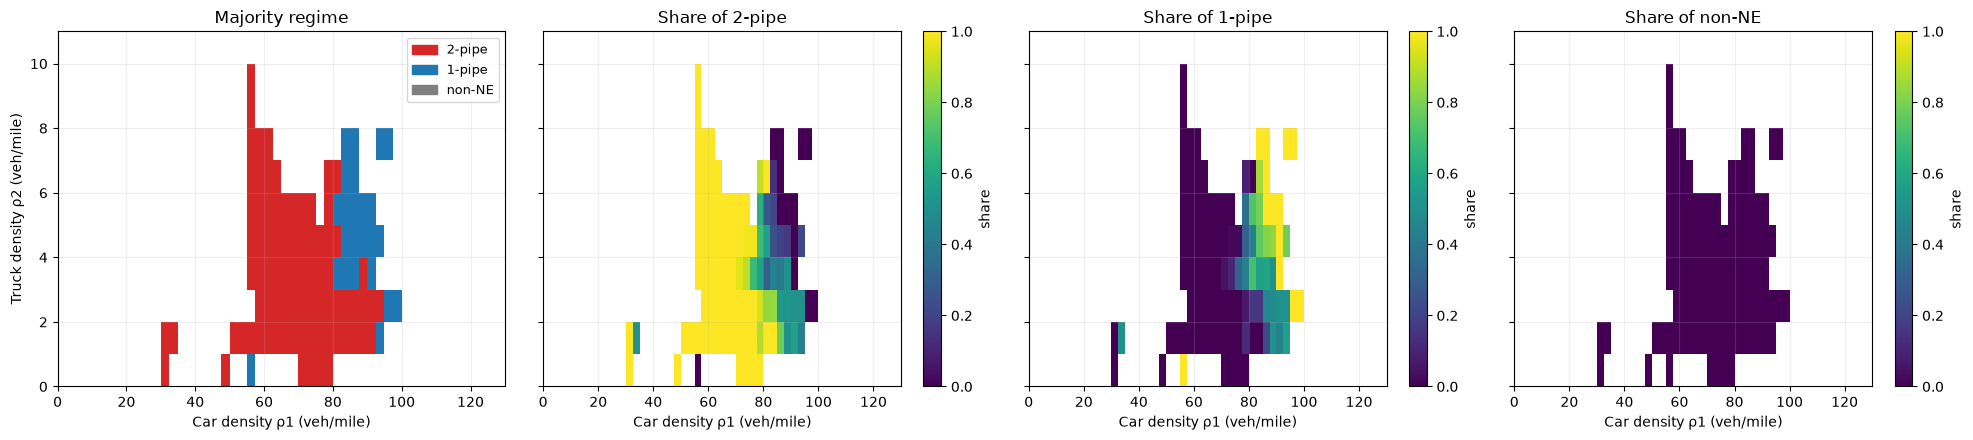

表示したマス: 106個 (スナップショット3件未満のマスは非表示)


In [74]:
# veh/km で表示
counts = plot_regime_heatmap(df_regime_nc)

# 論文と同じ veh/mile で表示（Fig.11/12の軸に合わせる場合）
counts = plot_regime_heatmap(df_regime_nc, in_vpm=True, bin_width1=2.5, bin_width2=1.0,
                             max_rho1=130, max_rho2=11)

### 余剰分割係数の計算

In [ ]:
#############################################################################
# Step 6: 余剰分割係数λの推定  論文Eq(12)-(14), Section 5.2.3
#   ※Pythonでは lambda が予約語なので、変数名は lam を使う
#############################################################################

# 論文Eq(13)：λを与えたときの各クラスの予測速度
#   û1 = u1( ρ1 / (p1* + λ s) ),  û2 = u2( ρ2 / (p2* + (1-λ) s) )
#   u1, u2 はクラス自身の名目速度関数(C-C: ロジスティック, T-T: アンダーウッド)
def predict_speed_with_lambda(df, lam, car_params, truck_params):
    p1 = df['p1_star'] + lam * df['s']
    p2 = df['p2_star'] + (1.0 - lam) * df['s']

    #入力の密度を変更し、u1_hatはその密度のときの速度の値が記録される
    u1_hat = logistic_speed_density(
        df['rho1'] / p1, car_params['ub'], car_params['uf'], car_params['rhoc'],
        car_params['theta1'], car_params['theta2']
    )
    u2_hat = underwood_speed_density(df['rho2'] / p2, truck_params['uf'], truck_params['rhoc'])
    return u1_hat, u2_hat

# 論文Eq(12)：損失関数 L(λ) = (1/T) Σt [ Σi wi |ũit - ûit| ]^2
#   各時刻で「重み付き絶対誤差の2クラス合計」を2乗し、時間で平均する
def surplus_split_loss(lam, df, car_params, truck_params, w1=0.5, w2=0.5):
    u1_hat, u2_hat = predict_speed_with_lambda(df, lam, car_params, truck_params)
    err_t = w1 * np.abs(df['u1_obs'] - u1_hat) + w2 * np.abs(df['u2_obs'] - u2_hat)
    return np.mean(err_t ** 2)

# 評価指標：クラス別MAEと重み付きMAE（論文Table 6）
def surplus_split_mae(lam, df, car_params, truck_params, w1=0.5, w2=0.5):
    u1_hat, u2_hat = predict_speed_with_lambda(df, lam, car_params, truck_params)
    mae1 = np.mean(np.abs(df['u1_obs'] - u1_hat))
    mae2 = np.mean(np.abs(df['u2_obs'] - u2_hat))
    return {'mae1': mae1, 'mae2': mae2, 'mae_weighted': w1 * mae1 + w2 * mae2}


# 論文Eq(14)：λ̂ = argmin L(λ)、λ∈[0,1] の1次元有界問題をBrent法で解く
def fit_surplus_split(df, car_params, truck_params, w1=0.5, w2=0.5):
    #surplus_split_lossの一番目の引数（lambda）を0から1まで動かしながら、一番小さくなった時のres.xがlambda
    res = minimize_scalar(
        surplus_split_loss, bounds=(0.0, 1.0), method='bounded',
        args=(df, car_params, truck_params, w1, w2)
    )
    return res.x

#cross validation　する必要がある？
def estimate_surplus_split(df_coop, car_params, truck_params, w1=0.5, w2=0.5,
                           test_size=0.3, k=10, random_state=42):
    """
    協力性ありのスナップショット(2-pipe かつ s>0)で余剰分割係数λを推定する。
    論文と同じく 70%/30% に分割し、学習データで k-fold 交差検証(k=10)を行う。

    df_coop: check_cooperation_existence の返り値（coop_exists, rho1, rho2, p1_star, p2_star, s,
             u1_obs, u2_obs 列を含む）
    car_params, truck_params: u*・p*の計算に使ったものと同じパラメータを渡すこと
    w1, w2: クラスの重み（論文はclass-based: w1=w2=0.5）

    戻り値: dict
      'lambda_hat'  : 学習データ全体で推定したλ
      'test_mae'    : テストデータでのクラス別MAE・重み付きMAE（km/h）
      'cv'          : 各foldのλ・検証MAEのDataFrame（論文Fig.16に相当）
      'train','test': 分割後のデータ
    """
    cols = ['rho1', 'rho2', 'p1_star', 'p2_star', 's', 'u1_obs', 'u2_obs']
    data = df_coop[df_coop['coop_exists']].dropna(subset=cols)
    print(f"λの推定に使うスナップショット(2-pipe かつ s>0): {len(data):,}件")
    if len(data) < k:
        raise ValueError(f"データが{len(data)}件しかなく、{k}-fold交差検証ができません")

    train, test = train_test_split(data, test_size=test_size, random_state=random_state)

    # k-fold交差検証（学習データをk分割し、k-1個で推定→残り1個で評価をk回）
    kf = KFold(n_splits=k, shuffle=True, random_state=random_state)
    cv_rows = []
    for fold, (tr_idx, va_idx) in enumerate(kf.split(train), start=1):
        tr, va = train.iloc[tr_idx], train.iloc[va_idx]
        lam_f = fit_surplus_split(tr, car_params, truck_params, w1, w2)
        mae_f = surplus_split_mae(lam_f, va, car_params, truck_params, w1, w2)
        cv_rows.append({'fold': fold, 'lambda': lam_f, **mae_f})
    cv = pd.DataFrame(cv_rows)

    # 学習データ全体でλを推定し、テストデータで評価
    lam_hat = fit_surplus_split(train, car_params, truck_params, w1, w2)
    test_mae = surplus_split_mae(lam_hat, test, car_params, truck_params, w1, w2)

    print(f"  学習 {len(train):,}件 / テスト {len(test):,}件")
    print(f"  {k}-fold CV: λ = {cv['lambda'].mean():.4f} ± {cv['lambda'].std():.4f}, "
          f"重み付きMAE = {cv['mae_weighted'].mean():.3f} ± {cv['mae_weighted'].std():.3f} km/h")
    print(f"  λ_hat = {lam_hat:.4f}  (論文: 0.8067)")
    print(f"  テストMAE: 車 {test_mae['mae1']:.3f}, トラック {test_mae['mae2']:.3f}, "
          f"重み付き {test_mae['mae_weighted']:.3f} km/h")
    print(f"           = 車 {test_mae['mae1'] / KM_TO_MILE:.3f}, トラック {test_mae['mae2'] / KM_TO_MILE:.3f}, "
          f"重み付き {test_mae['mae_weighted'] / KM_TO_MILE:.3f} mph  (論文: 2.32, 1.45, 1.89 mph)")

    return {'lambda_hat': lam_hat, 'test_mae': test_mae, 'cv': cv, 'train': train, 'test': test}


# 論文Fig.17風：λを0〜1で動かしたときの損失関数の形
def plot_surplus_split_loss(df, car_params, truck_params, lam_hat=None, w1=0.5, w2=0.5, n_grid=201):
    lams = np.linspace(0.0, 1.0, n_grid)
    losses = [surplus_split_loss(l, df, car_params, truck_params, w1, w2) for l in lams]

    fig, ax = plt.subplots(figsize=(7, 4.5))
    ax.plot(lams, losses, color='tab:blue')
    if lam_hat is not None:
        ax.scatter([lam_hat], [surplus_split_loss(lam_hat, df, car_params, truck_params, w1, w2)],
                   color='red', zorder=3, label=f'λ̂ = {lam_hat:.4f}')
        ax.legend()
    ax.set_xlabel('Surplus split factor λ')
    ax.set_ylabel('Loss L(λ)  ((km/h)$^2$)')
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


# 論文Eq(15)(16)：台数比で正規化した分割係数と公平性指標
#   Pi = Ni*PCEi / Σ Nj*PCEj,  λ̃1 = λ̂/P1,  λ̃2 = (1-λ̂)/P2,  δ = |λ̃1 - λ̃2|
def compute_equity_metric(lam_hat, n_car, n_truck, pce_car=1.0, pce_truck=1.5):
    w_car, w_truck = n_car * pce_car, n_truck * pce_truck
    P1 = w_car / (w_car + w_truck)
    P2 = w_truck / (w_car + w_truck)
    lam1 = lam_hat / P1
    lam2 = (1.0 - lam_hat) / P2
    delta = abs(lam1 - lam2)
    print(f"P1 = {P1:.4f}, P2 = {P2:.4f}")
    print(f"λ~1 = {lam1:.3f}, λ~2 = {lam2:.3f}, δ = {delta:.3f}  (論文: 0.84, 4.82, 3.98)")
    return {'P1': P1, 'P2': P2, 'lambda_tilde1': lam1, 'lambda_tilde2': lam2, 'delta': delta}

λの推定に使うスナップショット(2-pipe かつ s>0): 862件
  学習 603件 / テスト 259件
  10-fold CV: λ = 0.0000 ± 0.0000, 重み付きMAE = 6.095 ± 0.269 km/h
  λ_hat = 0.0000  (論文: 0.8067)
  テストMAE: 車 5.271, トラック 7.328, 重み付き 6.299 km/h
           = 車 3.275, トラック 4.553, 重み付き 3.914 mph  (論文: 2.32, 1.45, 1.89 mph)


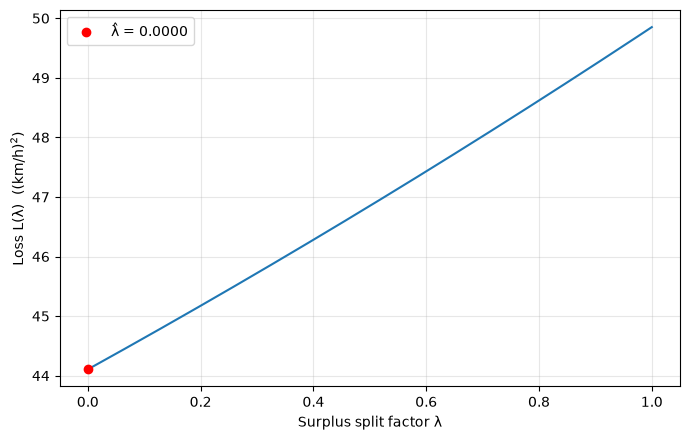

,fold,lambda,mae1,mae2,mae_weighted
0,1,0.000006,4.869130,7.481635,6.175382
1,2,0.000006,5.573911,7.409957,6.491934
2,3,0.000006,5.286319,7.177522,6.231921
3,4,0.000006,4.509678,6.935603,5.722641
4,5,0.000006,5.065136,6.772540,5.918838
5,6,0.000006,4.744017,6.572756,5.658387
6,7,0.000006,5.480630,7.038719,6.259674
7,8,0.000006,5.489331,6.770772,6.130051
8,9,0.000006,5.334343,7.380546,6.357445
9,10,0.000006,4.884725,7.116352,6.000539


(A) df_final: 車 1475台, トラック 53台  (論文: 1401台, 39台)
P1 = 0.9489, P2 = 0.0511
λ~1 = 0.000, λ~2 = 19.553, δ = 19.553  (論文: 0.84, 4.82, 3.98)
(B) 生データ レーン2〜4: 車 2684台, トラック 133台
P1 = 0.9308, P2 = 0.0692
λ~1 = 0.000, λ~2 = 14.454, δ = 14.454  (論文: 0.84, 4.82, 3.98)


In [79]:
res = estimate_surplus_split(df_coop, results_cc_strong_constraint, results_tt_strong_constraint)
plot_surplus_split_loss(res['train'], results_cc_strong_constraint, results_tt_strong_constraint, res['lambda_hat'])
display(res['cv'])   # foldごとのαとMAE（Fig.16に相当）

# (A) 論文と同じ考え方：df_final（フィルタ後の追従データ）に出てくる車両の台数
veh_final = df_final[['time_period', 'Vehicle_ID', 'v_Class']].drop_duplicates()
n_car_A   = (veh_final['v_Class'] == 2).sum()
n_truck_A = (veh_final['v_Class'] == 3).sum()
print(f"(A) df_final: 車 {n_car_A}台, トラック {n_truck_A}台  (論文: 1401台, 39台)")
eq_A = compute_equity_metric(res['lambda_hat'], n_car=n_car_A, n_truck=n_truck_A)

# (B) マクロデータと同じ範囲：生データdfのレーン2〜4に一度でも現れた車両の台数
veh_raw = df[df['Lane_ID'].isin([2, 3, 4]) & df['v_Class'].isin([2, 3])]
veh_raw = veh_raw[['time_period', 'Vehicle_ID', 'v_Class']].drop_duplicates()
n_car_B   = (veh_raw['v_Class'] == 2).sum()
n_truck_B = (veh_raw['v_Class'] == 3).sum()
print(f"(B) 生データ レーン2〜4: 車 {n_car_B}台, トラック {n_truck_B}台")
eq_B = compute_equity_metric(res['lambda_hat'], n_car=n_car_B, n_truck=n_truck_B)

In [ ]:
tr = res['train']

# (1) 推定に使った2-pipeデータで、車とトラックがu*からどれだけずれているか
print(tr[['du1', 'du2']].describe())
print("車が u*±eps 以内の割合:", (tr['du1'].abs() <= 2.0).mean())

# (2) αを変えたとき、予測速度が観測速度に比べてどれだけずれるか（平均残差, km/h）
for a in [0.0, 0.25, 0.5, 0.75, 1.0]:
    u1h, u2h = predict_speed_with_lambda(tr, a, results_cc_strong_constraint, results_tt_strong_constraint)
    print(f"α={a:.2f}: 車 ũ1-û1 = {(tr['u1_obs'] - u1h).mean():+.2f},  "
          f"トラック ũ2-û2 = {(tr['u2_obs'] - u2h).mean():+.2f}")

# (3) CVの各foldでも0に張り付いているか
print(res['cv']['lambda'].describe())

               du1          du2
count  1632.000000  1632.000000
mean      3.685487     4.620902
std       2.310218     3.352105
min      -1.950772    -1.968113
25%       2.273689     2.372416
50%       3.578699     4.194284
75%       5.200418     6.794902
max      11.600811    21.366421
車が u*±eps 以内の割合: 0.20710784313725492
α=0.00: 車 ũ1-û1 = +3.69,  トラック ũ2-û2 = +3.72
α=0.25: 車 ũ1-û1 = +3.65,  トラック ũ2-û2 = +3.95
α=0.50: 車 ũ1-û1 = +3.62,  トラック ũ2-û2 = +4.17
α=0.75: 車 ũ1-û1 = +3.59,  トラック ũ2-û2 = +4.39
α=1.00: 車 ũ1-û1 = +3.55,  トラック ũ2-û2 = +4.62
count    1.000000e+01
mean     5.960861e-06
std      8.928511e-22
min      5.960861e-06
25%      5.960861e-06
50%      5.960861e-06
75%      5.960861e-06
max      5.960861e-06
Name: alpha, dtype: float64


In [39]:
print(tr[['s', 'p1_star', 'p2_star']].describe())

                 s      p1_star      p2_star
count  1632.000000  1632.000000  1632.000000
mean      0.004052     0.883940     0.112008
std       0.001691     0.048624     0.047106
min       0.000050     0.707010     0.027583
25%       0.002490     0.851175     0.075615
50%       0.003980     0.882125     0.113284
75%       0.005392     0.921127     0.143450
max       0.010328     0.971206     0.282662
